# Deep Learning Training - LSTM Stock Price Prediction

In [1]:
import os
import sys

# 1. Get the absolute path to the 'root
root_path = os.path.abspath(os.path.join('..'))

# 2. Add the root path to sys.path to import 'src'
if root_path not in sys.path:
    sys.path.append(root_path)

# 3. Now import using the 'src.' prefix
from src.data_loader import load_and_preprocess_stock_data, get_clean_data_path, MODELS_DIR

In [2]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from src.models import LSTMModel

TARGET_TICKER = "AAPL"
START_DATE = "2023-01-01"
END_DATE = "2025-01-01"
LSTM_SEQUENCE_LENGTH = 60
TRAIN_SPLIT_RATIO = 0.8

LSTM_INPUT_SIZE = 12
LSTM_HIDDEN_SIZE = 64
LSTM_NUM_LAYERS = 2
LSTM_OUTPUT_SIZE = 1
LEARNING_RATE = 0.001
NUM_EPOCHS = 100
BATCH_SIZE = 32
DROPOUT_RATE = 0.2

os.makedirs(MODELS_DIR, exist_ok=True)
LSTM_MODEL_PATH = os.path.join(MODELS_DIR, "lstm_model.pth")

In [3]:
print("--- Loading and Preprocessing Data for LSTM Training ---")
scaled_df, X_train_np, y_train_np, X_test_np, y_test_np, scaler_features_obj, scaler_target_obj, feature_columns = \
    load_and_preprocess_stock_data(
        ticker=TARGET_TICKER,
        start_date=START_DATE,
        end_date=END_DATE,
        sequence_length=LSTM_SEQUENCE_LENGTH,
        split_ratio=TRAIN_SPLIT_RATIO
    )

X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(X_test_np, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.float32).unsqueeze(1)

print(f"X_train tensor shape: {X_train.shape}, y_train tensor shape: {y_train.shape}")
print(f"X_test tensor shape: {X_test.shape}, y_test tensor shape: {y_test.shape}")

--- Loading and Preprocessing Data for LSTM Training ---
Loading data for AAPL from 2023-01-01 to 2025-01-01...


[*********************100%***********************]  1 of 1 completed

Data loading and preprocessing complete. X_train shape: (314, 60, 12), X_test shape: (79, 60, 12)
Cleaned data saved to d:\USD\capstone\data\clean_stock_data_AAPL.csv
X_train tensor shape: torch.Size([314, 60, 12]), y_train tensor shape: torch.Size([314, 1])
X_test tensor shape: torch.Size([79, 60, 12]), y_test tensor shape: torch.Size([79, 1])


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = LSTMModel(
    input_size=LSTM_INPUT_SIZE,
    hidden_size=LSTM_HIDDEN_SIZE,
    num_layers=LSTM_NUM_LAYERS,
    output_size=LSTM_OUTPUT_SIZE,
    dropout_rate=DROPOUT_RATE
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("\n--- Model Architecture ---")
print(model)

Using device: cpu

--- Model Architecture ---
LSTMModel(
  (lstm): LSTM(12, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [5]:
print("\n--- Starting Model Training ---")
train_losses = []
val_losses = []
best_val_loss = float('inf')

train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

for epoch in range(NUM_EPOCHS):
    model.train()
    batch_losses = []
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)

    model.eval()
    with torch.no_grad():
        X_test_gpu, y_test_gpu = X_test.to(device), y_test.to(device)
        val_outputs = model(X_test_gpu)
        val_loss = criterion(val_outputs, y_test_gpu).item()
        val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), LSTM_MODEL_PATH)
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f} (Saved Best Model)")
    else:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

print("--- Training Complete ---")


--- Starting Model Training ---
Epoch 1/100, Train Loss: 0.0849, Val Loss: 0.0968 (Saved Best Model)
Epoch 2/100, Train Loss: 0.0200, Val Loss: 0.1020
Epoch 3/100, Train Loss: 0.0154, Val Loss: 0.0934 (Saved Best Model)
Epoch 4/100, Train Loss: 0.0104, Val Loss: 0.0354 (Saved Best Model)
Epoch 5/100, Train Loss: 0.0072, Val Loss: 0.0193 (Saved Best Model)
Epoch 6/100, Train Loss: 0.0046, Val Loss: 0.0088 (Saved Best Model)
Epoch 7/100, Train Loss: 0.0042, Val Loss: 0.0176
Epoch 8/100, Train Loss: 0.0037, Val Loss: 0.0146
Epoch 9/100, Train Loss: 0.0034, Val Loss: 0.0089
Epoch 10/100, Train Loss: 0.0035, Val Loss: 0.0070 (Saved Best Model)
Epoch 11/100, Train Loss: 0.0036, Val Loss: 0.0032 (Saved Best Model)
Epoch 12/100, Train Loss: 0.0035, Val Loss: 0.0062
Epoch 13/100, Train Loss: 0.0038, Val Loss: 0.0126
Epoch 14/100, Train Loss: 0.0039, Val Loss: 0.0078
Epoch 15/100, Train Loss: 0.0029, Val Loss: 0.0131
Epoch 16/100, Train Loss: 0.0033, Val Loss: 0.0042
Epoch 17/100, Train Loss: 0

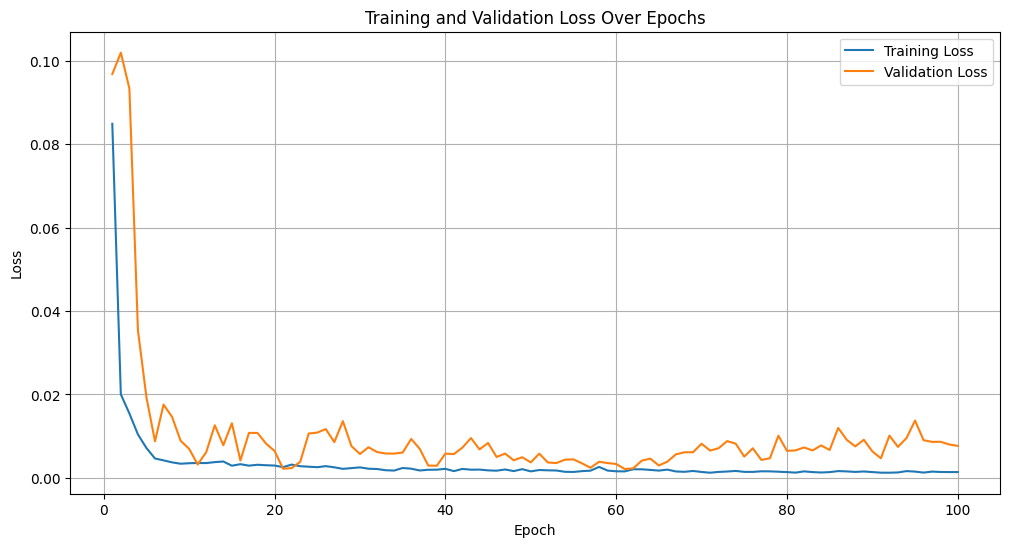

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label='Training Loss')
plt.plot(range(1, NUM_EPOCHS + 1), val_losses, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()


--- Evaluating Model on Test Set ---


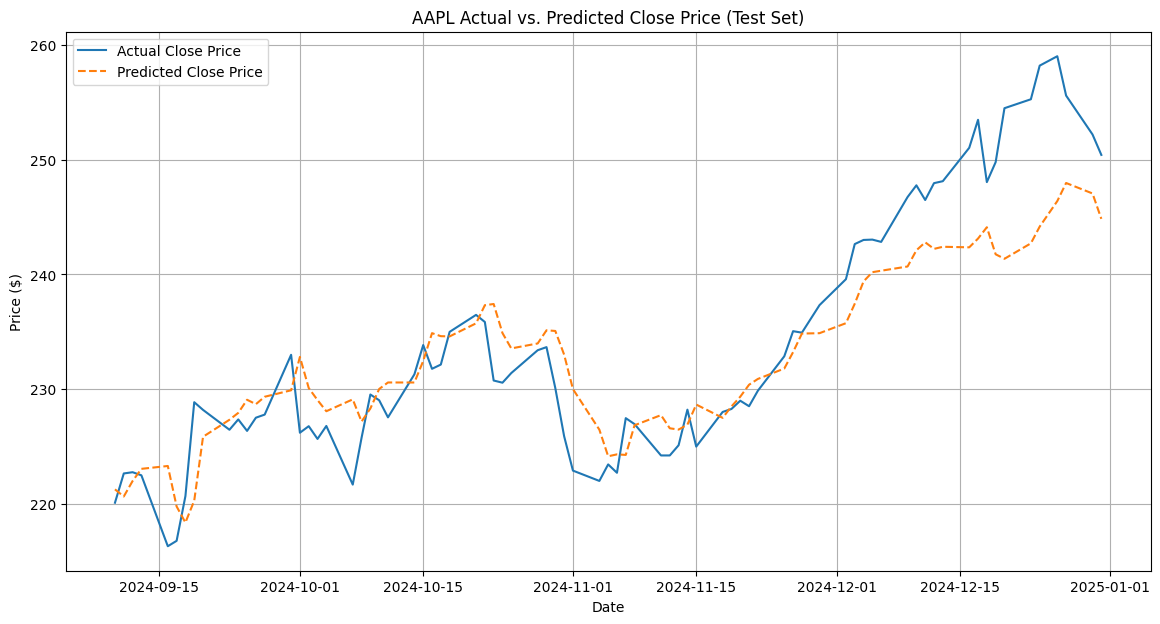

Root Mean Squared Error (RMSE) on Test Set: 4.89

--- Training and model saving complete. The LSTM model is ready for integration. ---


In [7]:
print("\n--- Evaluating Model on Test Set ---")
model.load_state_dict(torch.load(LSTM_MODEL_PATH, map_location=device, weights_only=True))
model.eval()

with torch.no_grad():
    X_test_gpu, y_test_gpu = X_test.to(device), y_test.to(device)
    test_predictions_scaled = model(X_test_gpu).cpu().numpy()

    test_predictions = scaler_target_obj.inverse_transform(test_predictions_scaled)
    y_test_actual = scaler_target_obj.inverse_transform(y_test_np.reshape(-1, 1))

original_df_dates = pd.read_csv(
    get_clean_data_path(TARGET_TICKER),
    index_col='Date',
    parse_dates=True
).index
test_start_index = len(X_train_np) + LSTM_SEQUENCE_LENGTH
test_dates = original_df_dates[test_start_index : test_start_index + len(y_test_actual)]

plt.figure(figsize=(14, 7))
plt.plot(test_dates, y_test_actual, label='Actual Close Price')
plt.plot(test_dates, test_predictions, label='Predicted Close Price', linestyle='--')
plt.title(f'{TARGET_TICKER} Actual vs. Predicted Close Price (Test Set)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.grid(True)
plt.legend()
plt.show()

rmse = np.sqrt(np.mean((test_predictions - y_test_actual)**2))
print(f"Root Mean Squared Error (RMSE) on Test Set: {rmse:.2f}")
print("\n--- Training and model saving complete. The LSTM model is ready for integration. ---")